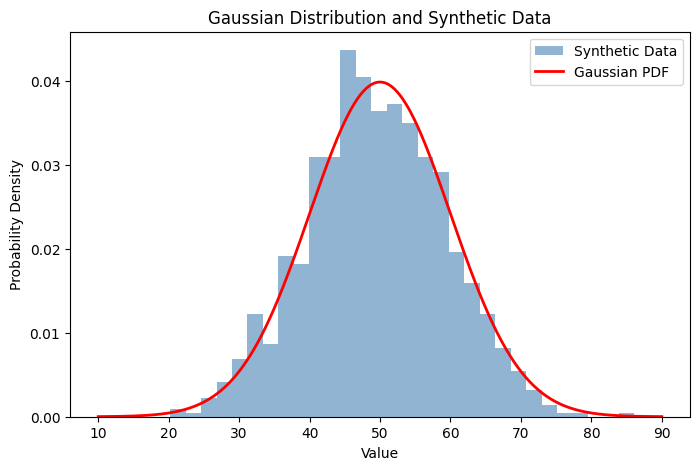

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

>>> Training VAE Model...
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - loss: 0.2033
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.1480
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.1401
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


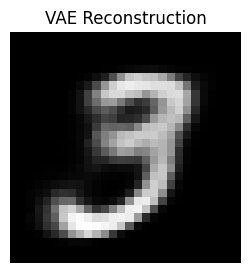

In [1]:
# Roll No: BT23F05F060

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import tensorflow as tf
from tensorflow.keras import layers, Model

# ==================================================
# Part 1: Gaussian Distribution & Data Sampling
# ==================================================
# Define distribution parameters
mu_val = 50.0
sigma_val = 10.0

# Generate synthetic samples
synthetic_data = np.random.normal(loc=mu_val, scale=sigma_val, size=1000)

# Compute Probability Density Function (PDF)
x_axis = np.linspace(10, 90, 1000)
pdf_curve = norm.pdf(x_axis, loc=mu_val, scale=sigma_val)

# Data visualization using object-oriented Matplotlib
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(synthetic_data, bins=30, density=True, alpha=0.6, color='steelblue', label="Synthetic Data")
ax.plot(x_axis, pdf_curve, color='red', linewidth=2, label="Gaussian PDF")
ax.set_xlabel("Value")
ax.set_ylabel("Probability Density")
ax.set_title("Gaussian Distribution and Synthetic Data")
ax.legend()
plt.show()

# ==================================================
# Part 2: Variational Autoencoder (VAE) on MNIST
# ==================================================
# Load and reshape the dataset
(train_images, _), _ = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(-1, 784).astype("float32") / 255.0

# Build Encoder network
vae_input = layers.Input(shape=(784,))
encoder_hidden = layers.Dense(128, activation="relu")(vae_input)
z_mean = layers.Dense(8, name="latent_mean")(encoder_hidden)
z_log_var = layers.Dense(8, name="latent_log_var")(encoder_hidden)

# Reparameterization trick (Sampling function)
def sample_latent(args):
    mean, log_var = args
    epsilon = tf.random.normal(shape=tf.shape(mean))
    return mean + tf.exp(0.5 * log_var) * epsilon

# Apply sampling layer
latent_space = layers.Lambda(sample_latent, name="z_sampling")([z_mean, z_log_var])

# Build Decoder network
decoder_hidden = layers.Dense(128, activation="relu")(latent_space)
vae_output = layers.Dense(784, activation="sigmoid")(decoder_hidden)

# Compile and train the VAE model
vae_model = Model(inputs=vae_input, outputs=vae_output, name="VAE")
vae_model.compile(optimizer="adam", loss="binary_crossentropy")

print("\n>>> Training VAE Model...")
vae_model.fit(train_images, train_images, epochs=3, batch_size=128)

# Reconstruct a single image for testing
reconstructed_img = vae_model.predict(train_images[:1])

# Visualize the reconstructed image
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(reconstructed_img.reshape(28, 28), cmap="gray")
ax.axis("off")
ax.set_title("VAE Reconstruction")
plt.show()